
# Install required libraries


In [ ]:

!pip install -q xarray netCDF4 h5netcdf cftime


## Import libraries


In [ ]:


# ==========================================
# Import libraries
# ==========================================
import os
import zipfile
import xarray as xr
import matplotlib.pyplot as plt


In [ ]:


# ==========================================
# Unzip file
# ==========================================
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)


In [3]:


# ==========================================
# Find .nc file
# ==========================================
nc_files = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".nc"):
            nc_files.append(os.path.join(root, file))

print("NetCDF Files Found:")
for f in nc_files:
    print(f)

nc_path = nc_files[0]

# ==========================================
# Open NetCDF without decoding time
# ==========================================
ds = xr.open_dataset(nc_path, decode_times=False)

print("\nDataset loaded successfully!\n")

ds

NetCDF Files Found:
/content/netcdf_data/ESACCI-WATERVAPOUR-L3S-LP-MERGED-MZM-5deg-1985-2019_v3.3.nc

Dataset loaded successfully!



<xarray.Dataset> Size: 8MB
Dimensions:       (lat: 36, bnds: 2, time: 420, plev: 28)
Coordinates:
  * lat           (lat) float32 144B 87.5 82.5 77.5 72.5 ... -77.5 -82.5 -87.5
  * time          (time) float64 3kB 60.5 61.5 62.5 63.5 ... 477.5 478.5 479.5
  * plev          (plev) float32 112B 300.0 250.0 200.0 170.0 ... 0.2 0.15 0.1
Dimensions without coordinates: bnds
Data variables:
    lat_bnds      (lat, bnds) float32 288B ...
    time_bnds     (time, bnds) float64 7kB ...
    zmh2o         (time, plev, lat) float32 2MB ...
    zmh2o_std     (time, plev, lat) float32 2MB ...
    zmh2o_err     (time, plev, lat) float32 2MB ...
    zmh2o_nr      (time, plev, lat) float32 2MB ...
    quality_flag  (time, plev, lat) float32 2MB ...
Attributes: (12/36)
    title:                      ESA CCI level 3 vertically resolved merged mo...
    institution:                Reading University
    source:                     SPARC Data Initiative water vapour climatolog...
    references:                 Hegglin et al., ESSD, https://doi.org/10.5194...
    history:                    Product generated using updated merging algor...
    tracking_id:                ee307c3a-9d50-4140-b66e-9de5f818f4db
    ...                         ...
    licence:                    ESA Climate Change Initiative Data Policy: fr...
    platform:                   ERBS, UARS, SPOT-4, Odin, Meteor-3M, Envisat,...
    sensor:                     SAGE II (v7), UARS-MLS (v6), HALOE (v19), SAG...
    key_variables:              mole_fraction_of_water_vapor_in_air
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  5

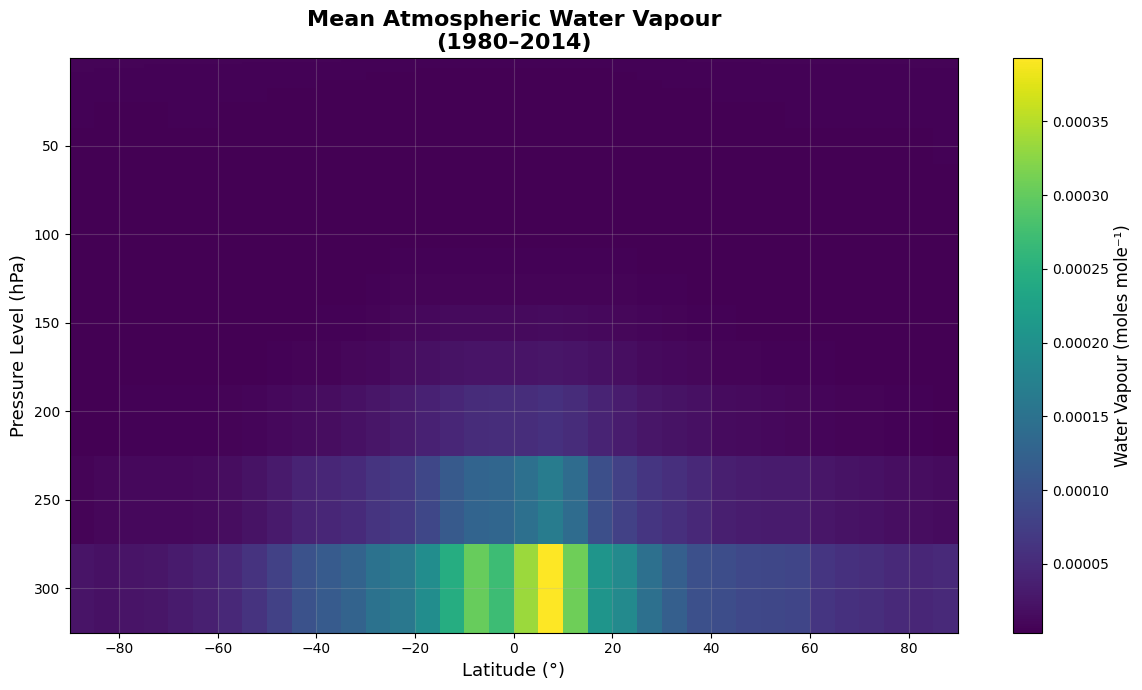

In [8]:
import matplotlib.pyplot as plt

# Calculate the mean over all time steps
mean_zmh2o = ds["zmh2o"].mean(dim="time")

# Create figure
plt.figure(figsize=(12, 7))

# Plot
im = plt.pcolormesh(
    ds["lat"],
    ds["plev"],
    mean_zmh2o,
    shading="auto",
    cmap="viridis"
)

# Invert pressure axis
plt.gca().invert_yaxis()

# Labels
plt.xlabel("Latitude (°)", fontsize=13)
plt.ylabel("Pressure Level (hPa)", fontsize=13)
plt.title("Mean Atmospheric Water Vapour\n(1980–2014)", fontsize=16, weight="bold")

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label("Water Vapour (moles mole⁻¹)", fontsize=12)

# Grid
plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

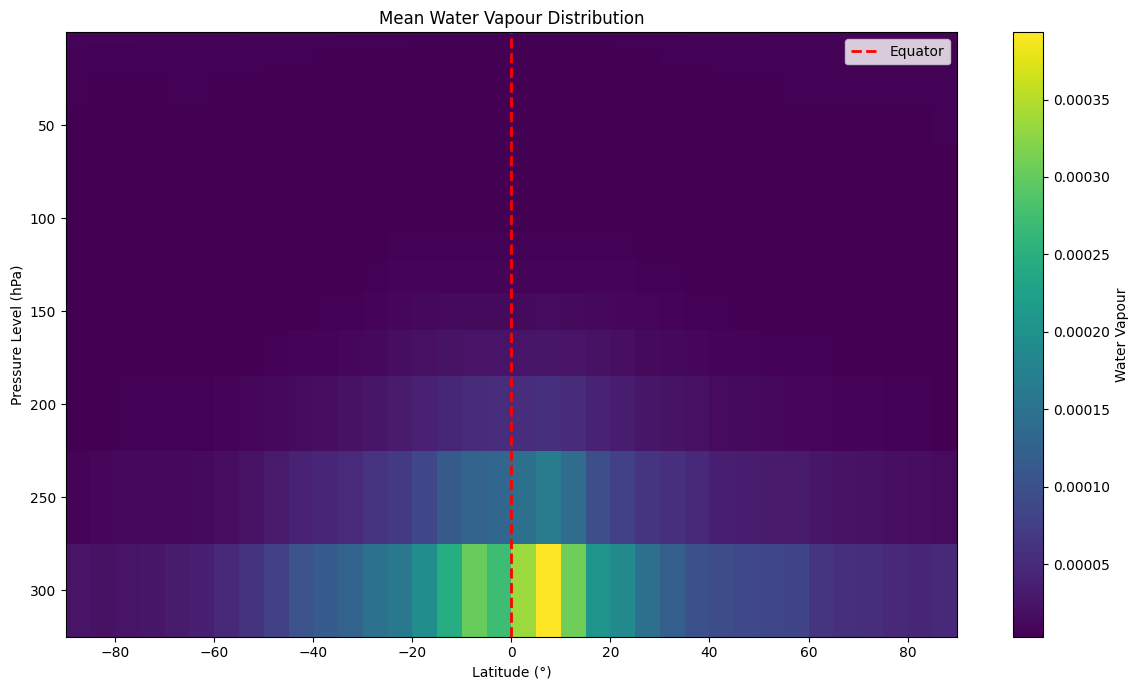

In [11]:
import matplotlib.pyplot as plt

mean_zmh2o = ds["zmh2o"].mean(dim="time")

plt.figure(figsize=(12,7))

im = plt.pcolormesh(
    ds.lat,
    ds.plev,
    mean_zmh2o,
    shading="auto",
    cmap="viridis"
)

# Equator
plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Equator"
)

plt.legend()

plt.gca().invert_yaxis()

plt.xlabel("Latitude (°)")
plt.ylabel("Pressure Level (hPa)")
plt.title("Mean Water Vapour Distribution")

cbar = plt.colorbar(im)
cbar.set_label("Water Vapour")

plt.tight_layout()

plt.show()

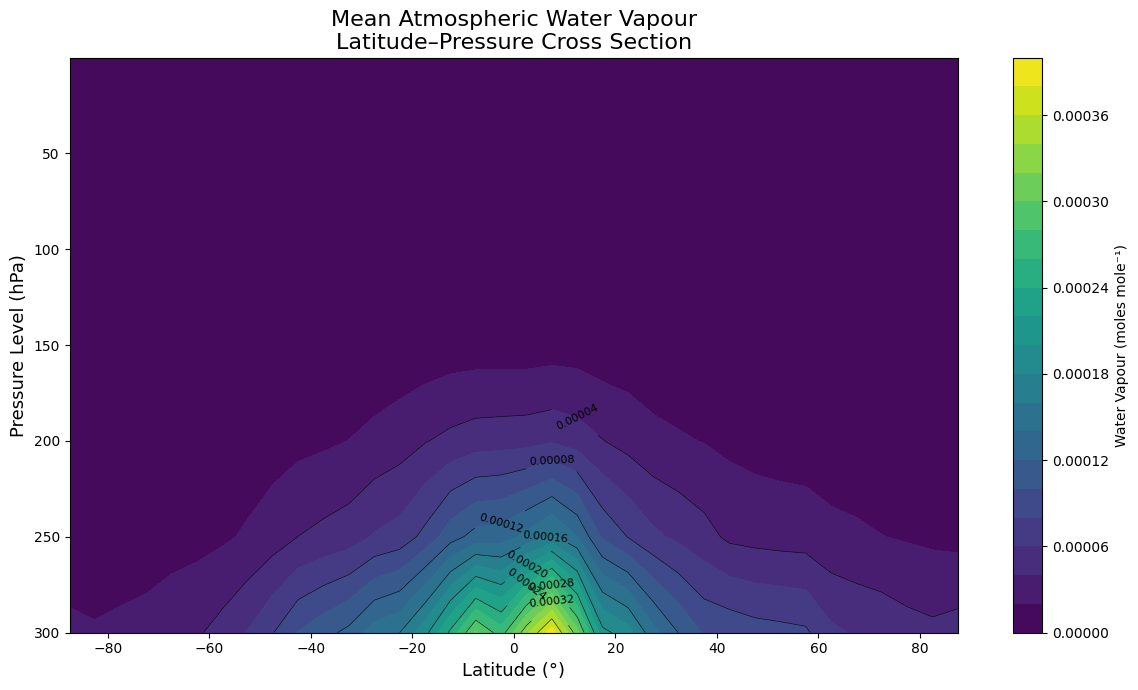

In [12]:
import matplotlib.pyplot as plt
import numpy as np

mean_zmh2o = ds["zmh2o"].mean(dim="time")

plt.figure(figsize=(12,7))

# Filled contours
cf = plt.contourf(
    ds["lat"],
    ds["plev"],
    mean_zmh2o,
    levels=20,
    cmap="viridis"
)

# Contour lines
cs = plt.contour(
    ds["lat"],
    ds["plev"],
    mean_zmh2o,
    levels=10,
    colors="black",
    linewidths=0.4
)

plt.clabel(cs, inline=True, fontsize=8)

plt.gca().invert_yaxis()

plt.xlabel("Latitude (°)", fontsize=13)
plt.ylabel("Pressure Level (hPa)", fontsize=13)
plt.title("Mean Atmospheric Water Vapour\nLatitude–Pressure Cross Section", fontsize=16)

cbar = plt.colorbar(cf)
cbar.set_label("Water Vapour (moles mole⁻¹)")

plt.tight_layout()
plt.show()

In [13]:
import numpy as np

mean_zmh2o = ds["zmh2o"].mean(dim="time")

# Flatten the array and find the index of the maximum value
idx = np.unravel_index(np.nanargmax(mean_zmh2o.values), mean_zmh2o.shape)

pressure = float(ds.plev[idx[0]])
latitude = float(ds.lat[idx[1]])
value = float(mean_zmh2o.values[idx])

print(f"Maximum Water Vapour = {value:.6f}")
print(f"Latitude = {latitude:.1f}°")
print(f"Pressure Level = {pressure:.1f} hPa")

Maximum Water Vapour = 0.000393
Latitude = 7.5°
Pressure Level = 300.0 hPa


In [14]:
# Figure 1: Basic information from NetCDF file

print("===== NETCDF DATASET ANATOMY =====\n")

print("Dimensions:")
for dim, size in ds.sizes.items():
    print(f"  {dim}: {size}")

print("\nCoordinates:")
for coord in ds.coords:
    print(f"  {coord}: {ds[coord].shape}")

print("\nData Variables:")
for var in ds.data_vars:
    print(f"  {var}: {ds[var].dims} {ds[var].shape}")

print("\nGlobal Attributes:")
for key, value in list(ds.attrs.items())[:10]:
    print(f"  {key}: {value}")

===== NETCDF DATASET ANATOMY =====

Dimensions:
  lat: 36
  bnds: 2
  time: 420
  plev: 28

Coordinates:
  lat: (36,)
  plev: (28,)
  time: (420,)

Data Variables:
  lat_bnds: ('lat', 'bnds') (36, 2)
  time_bnds: ('time', 'bnds') (420, 2)
  zmh2o: ('time', 'plev', 'lat') (420, 28, 36)
  zmh2o_std: ('time', 'plev', 'lat') (420, 28, 36)
  zmh2o_err: ('time', 'plev', 'lat') (420, 28, 36)
  zmh2o_nr: ('time', 'plev', 'lat') (420, 28, 36)
  quality_flag: ('time', 'plev', 'lat') (420, 28, 36)

Global Attributes:
  title: ESA CCI level 3 vertically resolved merged monthly zonal mean water vapour product
  institution: Reading University
  source: SPARC Data Initiative water vapour climatologies, see Hegglin et al. (ESSD, 2021)
  references: Hegglin et al., ESSD, https://doi.org/10.5194/essd-2020-342, 2021 (input datasets); Hegglin et al., Nature Geosc., DOI: 10.1038/NGEO2236, 2014 (merging algorithm).
  history: Product generated using updated merging algorithm by Hegglin et al. (2014).
  tra

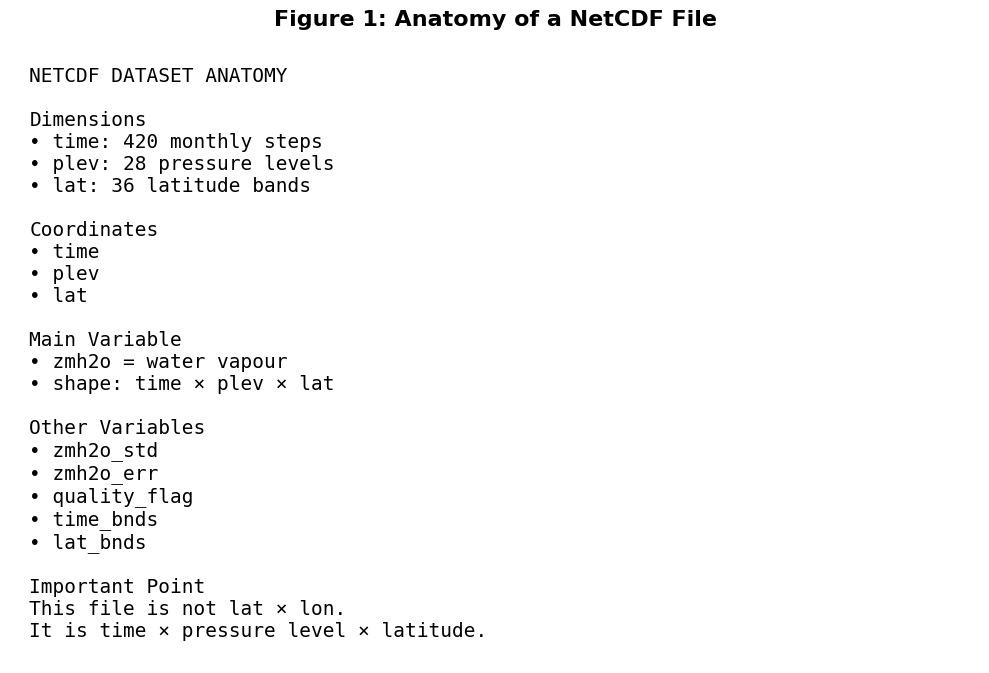

In [15]:
import matplotlib.pyplot as plt

text = """
NETCDF DATASET ANATOMY

Dimensions
• time: 420 monthly steps
• plev: 28 pressure levels
• lat: 36 latitude bands

Coordinates
• time
• plev
• lat

Main Variable
• zmh2o = water vapour
• shape: time × plev × lat

Other Variables
• zmh2o_std
• zmh2o_err
• quality_flag
• time_bnds
• lat_bnds

Important Point
This file is not lat × lon.
It is time × pressure level × latitude.
"""

plt.figure(figsize=(10, 7))
plt.text(0.02, 0.98, text, fontsize=14, va="top", family="monospace")
plt.axis("off")
plt.title("Figure 1: Anatomy of a NetCDF File", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')